In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,log_loss,brier_score_loss,classification_report,confusion_matrix)

The commented sections refer to results from my previous models, which were run using previous version of the feature engineering.

In [76]:
# df = pd.read_csv('./dataset/Predict Hair Fall.csv')
# df.head()


# print(df.isnull().sum())



In [77]:
# binary_cols = [
#     'Genetics', 
#     'Hormonal Changes', 
#     'Poor Hair Care Habits ', 
#     'Environmental Factors', 
#     'Smoking', 
#     'Weight Loss '
# ]

# # Define the mapping: 'Yes' to 1, 'No' to 0
# mapping = {'Yes': 1, 'No': 0}

# for col in binary_cols:
#     df[col] = df[col].replace(mapping)

# df.head()

In [78]:
# HIGH_CARDINALITY_COLS = [
#     'Medical Conditions', 
#     'Medications & Treatments', 
#     'Nutritional Deficiencies '
# ]

# # Combine any category that appears in less than 5% of the data into 'RARE'.
# RARITY_THRESHOLD = 0.05 
# MISSING_VALUE_STR = 'No Data'

# def group_rare_categories(df, column, threshold, missing_str):
#     """
#     Groups categories that are below a certain frequency threshold into a 
#     'RARE' group and standardizes missing values.
#     """
#     # print(f"Processing column: {column}")
    
#     df[column] = df[column].replace(missing_str, 'MISSING')
    
#     # value_counts = df[column].value_counts(normalize=True)
#     # rare_categories = value_counts[value_counts < threshold].index.tolist()
#     # print(f"Old unique values for {column}: {df[column].nunique()}")
#     # df[column] = df[column].replace(rare_categories, 'RARE')
#     # print(f"New unique values for {column}: {df[column].nunique()}")
#     # print(df[column].value_counts(normalize=True).round(3))
#     # print("-" * 50)
    
#     return df

# for col in HIGH_CARDINALITY_COLS:
#     df = group_rare_categories(df, col, RARITY_THRESHOLD, MISSING_VALUE_STR)

In [79]:
# stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
# df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)

In [80]:
# df['Age_Group'], age_bins = pd.qcut(
#     df['Age'], 
#     q=4, 
#     labels=False, 
#     duplicates='drop',
#     retbins=True
# )

# lowest_age = df['Age'].min()
# highest_age = df['Age'].max()
# print(f"The minimum age in the dataset is: {lowest_age}")
# print(f"The maximum age in the dataset is: {highest_age}")

# # Convert the bins array into readable ranges
# bin_ranges = []
# for i in range(len(age_bins) - 1):
#     # Format the range as [Lower Bound, Upper Bound]
#     lower = round(age_bins[i], 1)
#     upper = round(age_bins[i+1], 1)
#     bin_ranges.append(f"Bin {i}: ({lower} to {upper}]")

# print("--- AGE GROUP BINS (QUARTILES) ---")
# for range_str in bin_ranges:
#     print(range_str)
# print("-" * 50)

# # Replace the original 'Age' column with the new binned feature
# # df = df.drop(columns=['Age']) 

In [81]:
# df.head()

In [82]:
# sns.pairplot(df, height=3.5)
# plt.tight_layout()
# plt.show()

In [83]:
# selected_features_for_heatmap = ['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Hair Loss']
# correlation_matrix = df[selected_features_for_heatmap].corr()

# plt.figure(figsize=(10, 8))

# heatmap = sns.heatmap(
#     correlation_matrix,
#     annot=True,
#     cmap='coolwarm',
#     fmt='.2f',
#     linewidths=.5,
#     linecolor='black',
#     cbar_kws={'label': 'Correlation Coefficient'}
# )

# plt.title('Correlation Heatmap of Dataset Features', fontsize=16)
# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)

# plt.tight_layout()
# print("\nDisplaying the heatmap plot... Close the plot window to continue.")
# plt.show()

In [84]:
# One-hot encode Medical Conditions, Medications & TreatMents, Nutritional Deficiencies
# df = pd.get_dummies(df, columns=['Medical Conditions', 'Medications & Treatments','Nutritional Deficiencies '])
# df = df.astype(np.float32)

In [85]:
# # Define features and target
# features = [item for item in list(df.columns) if item not in ['Id','Hair Loss']]

# #Check dataset before splitting
# print(features)
# df.head()



In [86]:
# X = df[features]
# y = df['Hair Loss']

# # First split: separate test set (10% of data)
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X, y, test_size=0.1, random_state=42, stratify=y
# )

# # Second split: divide remaining data into train and validation (89% train, 11% validation of remaining data)
# # This will give us approximately 80-10-10 split of the total data
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
# )

# # Print the shapes of the resulting sets
# print("Training set shape:", X_train.shape)
# print("Validation set shape:", X_val.shape)
# print("Test set shape:", X_test.shape)

# # Calculate and print the percentages
# total_samples = len(df)
# print("\nData split percentages:")
# print(f"Training: {len(X_train)/total_samples:.1%}")
# print(f"Validation: {len(X_val)/total_samples:.1%}")
# print(f"Test: {len(X_test)/total_samples:.1%}")

In [87]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# # Fit on training data 
# X_train_scaled = scaler.fit_transform(X_train)

# # Transform validation and test sets
# X_val_scaled   = scaler.transform(X_val)
# X_test_scaled  = scaler.transform(X_test)

In [88]:
# from sklearn.linear_model import LogisticRegression
# # LASSO Logistic Regression 
# lasso_model = LogisticRegression(
#     penalty='l1',
#     solver='liblinear',   
#     max_iter=2000,       
#     random_state=42,
#     class_weight='balanced'   
# )

# # Ridge Logistic Regression
# ridge_model = LogisticRegression(
#     penalty='l2',
#     solver='lbfgs',       
#     max_iter=2000,
#     random_state=42,
#     class_weight='balanced'  
# )

In [89]:
# #fitting the models
# lasso_model.fit(X_train_scaled, y_train)
# ridge_model.fit(X_train_scaled, y_train)

In [90]:
# from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,log_loss,brier_score_loss,classification_report,confusion_matrix)
# # Training predictions
# lasso_train_pred = lasso_model.predict(X_train_scaled)
# ridge_train_pred = ridge_model.predict(X_train_scaled)
# print("=========== LASSO Logistic Regression Results ===========")
# # Validation predictions
# lasso_val_pred = lasso_model.predict(X_val_scaled)
# ridge_val_pred = ridge_model.predict(X_val_scaled)

# # Training metrics
# lasso_train_proba = lasso_model.predict_proba(X_train_scaled)[:, 1]
# print("\n--- TRAINING SET ---")
# print("Accuracy       :", accuracy_score(y_train, lasso_train_pred))
# print("Precision      :", precision_score(y_train, lasso_train_pred, zero_division=0))
# print("Recall         :", recall_score(y_train, lasso_train_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_train, lasso_train_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_train, lasso_train_proba))
# print("Log Loss       :", log_loss(y_train, lasso_train_proba))
# print("Brier Score    :", brier_score_loss(y_train, lasso_train_proba))

# # Validation metrics
# lasso_val_proba = lasso_model.predict_proba(X_val_scaled)[:, 1]
# print("\n--- VALIDATION SET ---")
# print("Accuracy       :", accuracy_score(y_val, lasso_val_pred))
# print("Precision      :", precision_score(y_val, lasso_val_pred, zero_division=0))
# print("Recall         :", recall_score(y_val, lasso_val_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_val, lasso_val_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_val, lasso_val_proba))
# print("Log Loss       :", log_loss(y_val, lasso_val_proba))
# print("Brier Score    :", brier_score_loss(y_val, lasso_val_proba))

# print("============================================")

# print("Ridge Logistic Regression Results")
# # Training metrics
# ridge_train_proba = ridge_model.predict_proba(X_train_scaled)[:, 1]
# print("\n--- TRAINING SET ---")
# print("Accuracy       :", accuracy_score(y_train, ridge_train_pred))
# print("Precision      :", precision_score(y_train, ridge_train_pred, zero_division=0))
# print("Recall         :", recall_score(y_train, ridge_train_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_train, ridge_train_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_train, ridge_train_proba))
# print("Log Loss       :", log_loss(y_train, ridge_train_proba))
# print("Brier Score    :", brier_score_loss(y_train, ridge_train_proba))

# # Validation metrics
# ridge_val_proba = ridge_model.predict_proba(X_val_scaled)[:, 1]
# print("\n--- VALIDATION SET ---")
# print("Accuracy       :", accuracy_score(y_val, ridge_val_pred))
# print("Precision      :", precision_score(y_val, ridge_val_pred, zero_division=0))
# print("Recall         :", recall_score(y_val, ridge_val_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_val, ridge_val_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_val, ridge_val_proba))
# print("Log Loss       :", log_loss(y_val, ridge_val_proba))
# print("Brier Score    :", brier_score_loss(y_val, ridge_val_proba))

In [91]:
# lasso_val_acc = accuracy_score(y_val, lasso_val_pred)
# ridge_val_acc = accuracy_score(y_val, ridge_val_pred)

In [92]:
# if ridge_val_acc > lasso_val_acc:
#     best_model = ridge_model
#     best_name = "Ridge (L2)"
# else:
#     best_model = lasso_model
#     best_name = "LASSO (L1)"

# print("\nBest model selected:", best_name)

In [93]:
# test_pred = best_model.predict(X_test_scaled)

In [94]:
# print("LOGISTIC REGRESSION – TEST SET PERFORMANCE")
# # 1. Predictions
# y_test_pred = best_model.predict(X_test_scaled)
# # 2. Probabilities for class 1 (Hair Loss)
# y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
# # 3. Metrics
# acc = accuracy_score(y_test, y_test_pred)
# prec= precision_score(y_test, y_test_pred, zero_division=0)
# rec = recall_score(y_test, y_test_pred, zero_division=0)
# f1  = f1_score(y_test, y_test_pred, zero_division=0)
# auc = roc_auc_score(y_test, y_test_proba)
# ll  = log_loss(y_test, y_test_proba)
# brier = brier_score_loss(y_test, y_test_proba)

# # 4. Print results
# print(f"Accuracy       : {acc:.4f}")
# print(f"Precision      : {prec:.4f}")
# print(f"Recall         : {rec:.4f}")
# print(f"F1 Score       : {f1:.4f}")
# print(f"ROC–AUC        : {auc:.4f}")
# print(f"Log Loss       : {ll:.4f}")
# print(f"Brier Score    : {brier:.4f}")



# # 5. Confusion matrix
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_test_pred))

In [95]:
# test_acc = accuracy_score(y_test, test_pred)
# print("Final Test Accuracy:", test_acc)

In [96]:
# from sklearn.metrics import confusion_matrix

# # Compute confusion matrix
# cm = confusion_matrix(y_test, test_pred)

# plt.figure(figsize=(5,4))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['No Hair Loss','Hair Loss'],
#     yticklabels=['No Hair Loss','Hair Loss']
# )
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Best Logistic Regression Model")
# plt.show()

In [97]:
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

In [98]:
# from sklearn.svm import LinearSVC
# from sklearn.calibration import CalibratedClassifierCV

# svm_linear = LinearSVC(C=1.0, class_weight='balanced',  max_iter=10000)
# svm_model = CalibratedClassifierCV(svm_linear)
# svm_model.fit(X_train_scaled, y_train)

In [99]:
# y_val_pred_svm = svm_model.predict(X_val_scaled)
# val_acc_svm = accuracy_score(y_val, y_val_pred_svm)

# print("=========== SVM (RBF) Results ===========")

# # Training predictions & probabilities
# svm_train_pred  = svm_model.predict(X_train_scaled)
# svm_train_proba = svm_model.predict_proba(X_train_scaled)[:, 1]

# print("\n--- TRAINING SET ---")
# print("Accuracy       :", accuracy_score(y_train, svm_train_pred))
# print("Precision      :", precision_score(y_train, svm_train_pred, zero_division=0))
# print("Recall         :", recall_score(y_train, svm_train_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_train, svm_train_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_train, svm_train_proba))
# print("Log Loss       :", log_loss(y_train, svm_train_proba))
# print("Brier Score    :", brier_score_loss(y_train, svm_train_proba))

# # Validation predictions & probabilities
# svm_val_pred  = svm_model.predict(X_val_scaled)
# svm_val_proba = svm_model.predict_proba(X_val_scaled)[:, 1]

# print("\n--- VALIDATION SET ---")
# print("Accuracy       :", accuracy_score(y_val, svm_val_pred))
# print("Precision      :", precision_score(y_val, svm_val_pred, zero_division=0))
# print("Recall         :", recall_score(y_val, svm_val_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_val, svm_val_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_val, svm_val_proba))
# print("Log Loss       :", log_loss(y_val, svm_val_proba))
# print("Brier Score    :", brier_score_loss(y_val, svm_val_proba))

In [100]:
# cm = confusion_matrix(y_val, y_val_pred_svm)

# plt.figure(figsize=(5, 4))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['No Hair Loss', 'Hair Loss'],
#     yticklabels=['No Hair Loss', 'Hair Loss']
# )
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("SVM - Validation Confusion Matrix")
# plt.tight_layout()
# plt.show()

In [101]:
# print("SVM – TEST SET PERFORMANCE")

# # 1. Class predictions
# y_test_pred_svm = svm_model.predict(X_test_scaled)

# # 2. Probability predictions (requires probability=True)
# y_test_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# # 3. Metrics
# acc = accuracy_score(y_test, y_test_pred_svm)
# prec= precision_score(y_test, y_test_pred_svm, zero_division=0)
# rec = recall_score(y_test, y_test_pred_svm, zero_division=0)
# f1  = f1_score(y_test, y_test_pred_svm, zero_division=0)
# auc = roc_auc_score(y_test, y_test_proba_svm)
# ll  = log_loss(y_test, y_test_proba_svm)
# brier = brier_score_loss(y_test, y_test_proba_svm)

# # 4. Print results
# print(f"Accuracy       : {acc:.4f}")
# print(f"Precision      : {prec:.4f}")
# print(f"Recall         : {rec:.4f}")
# print(f"F1 Score       : {f1:.4f}")
# print(f"ROC–AUC        : {auc:.4f}")
# print(f"Log Loss       : {ll:.4f}")
# print(f"Brier Score    : {brier:.4f}")



# # 5. Confusion matrix
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_test_pred_svm))

In [102]:
# from sklearn.metrics import roc_auc_score, roc_curve

# y_test_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
# auc_svm = roc_auc_score(y_test, y_test_prob_svm)
# print("SVM ROC–AUC:", auc_svm)

# fpr, tpr, _ = roc_curve(y_test, y_test_prob_svm)

# plt.figure()
# plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_svm:.2f})")
# plt.plot([0, 1], [0, 1], linestyle="--")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("SVM ROC Curve")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [103]:
# from sklearn.neighbors import KNeighborsClassifier
# k_values = range(1, 101, 2) 
# best_k = None
# best_val_acc = 0.0
# best_knn_model = None

# for k in k_values:
#     knn = KNeighborsClassifier(
#         n_neighbors=k,
#         weights='uniform',
#         metric='minkowski',
#         p=2
#     )
    
#     knn.fit(X_train_scaled, y_train)
#     y_val_pred = knn.predict(X_val_scaled)
#     val_acc = accuracy_score(y_val, y_val_pred)
    
#     print(f"k = {k}: Validation Accuracy = {val_acc:.4f}")
    
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_k = k
#         best_knn_model = knn  


# print("Best k selected:", best_k)
# print("Best validation accuracy:", best_val_acc)

# final_knn_model = best_knn_model

In [104]:
# y_val_pred_knn = final_knn_model.predict(X_val_scaled)
# y_test_pred_knn = final_knn_model.predict(X_test_scaled)

# val_acc_knn = accuracy_score(y_val, y_val_pred_knn)
# print("\n=========== KNN Results ===========")

# # Training predictions & probabilities
# knn_train_pred  = final_knn_model.predict(X_train_scaled)
# knn_train_proba = final_knn_model.predict_proba(X_train_scaled)[:, 1]

# print("\n--- TRAINING SET ---")
# print("Accuracy       :", accuracy_score(y_train, knn_train_pred))
# print("Precision      :", precision_score(y_train, knn_train_pred, zero_division=0))
# print("Recall         :", recall_score(y_train, knn_train_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_train, knn_train_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_train, knn_train_proba))
# print("Log Loss       :", log_loss(y_train, knn_train_proba))
# print("Brier Score    :", brier_score_loss(y_train, knn_train_proba))

# # Validation predictions & probabilities
# knn_val_pred  = final_knn_model.predict(X_val_scaled)
# knn_val_proba = final_knn_model.predict_proba(X_val_scaled)[:, 1]

# print("\n--- VALIDATION SET ---")
# print("Accuracy       :", accuracy_score(y_val, knn_val_pred))
# print("Precision      :", precision_score(y_val, knn_val_pred, zero_division=0))
# print("Recall         :", recall_score(y_val, knn_val_pred, zero_division=0))
# print("F1 Score       :", f1_score(y_val, knn_val_pred, zero_division=0))
# print("ROC–AUC        :", roc_auc_score(y_val, knn_val_proba))
# print("Log Loss       :", log_loss(y_val, knn_val_proba))
# print("Brier Score    :", brier_score_loss(y_val, knn_val_proba))

In [105]:
# cm = confusion_matrix(y_val, y_val_pred_knn)

# plt.figure(figsize=(5, 4))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['No Hair Loss', 'Hair Loss'],
#     yticklabels=['No Hair Loss', 'Hair Loss']
# )
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("KNN - Validation Confusion Matrix")
# plt.tight_layout()
# plt.show()

In [106]:
# k_values = range(1, 101,2)
# val_accuracies = []

# for k in k_values:
#     knn = KNeighborsClassifier(
#         n_neighbors=k,
#         weights='uniform',
#         metric='minkowski',
#         p=2                     
#     )
    
#     knn.fit(X_train_scaled, y_train)
    
#     y_val_pred = knn.predict(X_val_scaled)
#     acc = accuracy_score(y_val, y_val_pred)
    
#     val_accuracies.append(acc)
#     print(f"k = {k}: Validation Accuracy = {acc:.4f}")

In [107]:
# k_best = k_values[val_accuracies.index(max(val_accuracies))]
# print("Best k:", k_best)

# knn_best = KNeighborsClassifier(
#     n_neighbors=k_best,
#     weights='distance',  
#     metric='minkowski',
#     p=2                   
# )

# knn_best.fit(X_train_scaled, y_train)

In [108]:
# print("KNN – TEST SET PERFORMANCE")

# # 1. Class predictions
# y_test_pred_knn = knn_best.predict(X_test_scaled)

# # 2. Probability predictions (KNN supports predict_proba)
# y_test_proba_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

# # 3. Metrics
# acc = accuracy_score(y_test, y_test_pred_knn)
# prec = precision_score(y_test, y_test_pred_knn, zero_division=0)
# rec  = recall_score(y_test, y_test_pred_knn, zero_division=0)
# f1   = f1_score(y_test, y_test_pred_knn, zero_division=0)
# auc  = roc_auc_score(y_test, y_test_proba_knn)
# ll   = log_loss(y_test, y_test_proba_knn)
# brie = brier_score_loss(y_test, y_test_proba_knn)

# # 4. Print results
# print(f"Accuracy       : {acc:.4f}")
# print(f"Precision      : {prec:.4f}")
# print(f"Recall         : {rec:.4f}")
# print(f"F1 Score       : {f1:.4f}")
# print(f"ROC–AUC        : {auc:.4f}")
# print(f"Log Loss       : {ll:.4f}")
# print(f"Brier Score    : {brier:.4f}")

# # 5. Confusion matrix
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_test_pred_knn))

In [109]:
# cm_test_knn = confusion_matrix(y_test, y_test_pred_knn)

# plt.figure(figsize=(5, 4))
# sns.heatmap(
#     cm_test_knn,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['No Hair Loss', 'Hair Loss'],
#     yticklabels=['No Hair Loss', 'Hair Loss']
# )
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("KNN - Test Confusion Matrix")
# plt.tight_layout()
# plt.show()

This is the new version of running the LR, SVM, and KNN models using the updated feature-engineering approach.

In [110]:
TARGET_COLUMN = 'Hair Loss'
FILE_PATH = './dataset/Predict Hair Fall.csv' 

try:
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded data from: {FILE_PATH}")
    print(f"Initial shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at '{FILE_PATH}'. Please ensure your file path is correct.")
    exit()


df.head()

Successfully loaded data from: ./dataset/Predict Hair Fall.csv
Initial shape: (999, 13)


,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,148393,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,155074,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,118261,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,111915,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [111]:
print(df.isnull().sum())

Id                           0
Genetics                     0
Hormonal Changes             0
Medical Conditions           0
Medications & Treatments     0
Nutritional Deficiencies     0
Stress                       0
Age                          0
Poor Hair Care Habits        0
Environmental Factors        0
Smoking                      0
Weight Loss                  0
Hair Loss                    0
dtype: int64


In [112]:
# Drop the non-predictive Id column
df = df.drop('Id', axis=1, errors='ignore') 

#Encoding and Feature Engineering
binary_cols = [
    'Genetics', 
    'Hormonal Changes', 
    'Poor Hair Care Habits ',
    'Environmental Factors', 
    'Smoking', 
    'Weight Loss '
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
        df[col] = df[col].fillna(0).astype(int) 


df.head()

,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,1,0,No Data,No Data,Magnesium deficiency,Moderate,19,1,1,0,0,0
1,0,0,Eczema,Antibiotics,Magnesium deficiency,High,43,1,1,0,0,0
2,0,0,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,1,1,0,1,0
3,1,1,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,1,1,0,0,0
4,0,0,Psoriasis,Accutane,Iron deficiency,Moderate,30,0,1,1,0,1


In [113]:
# One-Hot Encoding
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
if 'Stress' in df.columns:
    df['Stress'] = df['Stress'].map(stress_mapping)
    df['Stress'] = df['Stress'].fillna(1).astype(int)

multi_value_cols = ['Medical Conditions', 'Nutritional Deficiencies ', 'Medications & Treatments'] 

for col in multi_value_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[\[\]\"]', '', regex=True).fillna('')
        clean_col_name = col.strip().split(" ")[0].capitalize()
        new_count_col = f'Num_{clean_col_name}_Count'
        
        df[new_count_col] = df[col].apply(
            lambda x: len([item.strip() for item in x.split(',') if item.strip() != ''])
        )
        
        df = df.drop(col, axis=1)
df.head()        
        

,Genetics,Hormonal Changes,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss,Num_Medical_Count,Num_Nutritional_Count,Num_Medications_Count
0,1,0,1,19,1,1,0,0,0,1,1,1
1,0,0,2,43,1,1,0,0,0,1,1,1
2,0,0,1,26,1,1,0,1,0,1,1,1
3,1,1,1,46,1,1,0,0,0,1,1,1
4,0,0,1,30,0,1,1,0,1,1,1,1


In [114]:
if 'Age' in df.columns and 'Genetics' in df.columns and 'Poor Hair Care Habits ' in df.columns and 'Smoking' in df.columns:
    
    df['Age_x_Genetics'] = df['Age'] * df['Genetics']
    df['Smoking_x_PoorHairCare'] = df['Smoking'] * df['Poor Hair Care Habits ']


numerical_cols = ['Age', 'Num_Medical_Count', 'Num_Nutritional_Count', 'Num_Medications_Count', 'Age_x_Genetics'] 
scaler = StandardScaler()

for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
        # Apply scaling
        df[[col]] = scaler.fit_transform(df[[col]])


In [115]:
'''
columns_to_drop_final = [
    # 'Stress', 
    # 'Hormonal Changes', 
    # 'Environmental Factors', 
    'Poor Hair Care Habits ',
    'Smoking',
    'Age'
]
print(f"\n--- Feature Removal: Dropping {len(columns_to_drop_final)} weak features (r < 0.03) ---")
df = df.drop(columns=columns_to_drop_final, errors='ignore')
'''

'\ncolumns_to_drop_final = [\n    # \'Stress\', \n    # \'Hormonal Changes\', \n    # \'Environmental Factors\', \n    \'Poor Hair Care Habits \',\n    \'Smoking\',\n    \'Age\'\n]\nprint(f"\n--- Feature Removal: Dropping {len(columns_to_drop_final)} weak features (r < 0.03) ---")\ndf = df.drop(columns=columns_to_drop_final, errors=\'ignore\')\n'

In [116]:
# Data Split
if TARGET_COLUMN not in df.columns:
    print(f"\nERROR: Target column '{TARGET_COLUMN}' not found. Please check the name.")
    exit()

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print("\n--- Preprocessing Complete ---")
print(f"Shape of X_train (Features for Training): {X_train.shape}")
print("\nFirst 5 rows of the NEW training data (X_train):")
print(X_train.head())
print("\nVerify that all remaining columns are numerical (0, 1, or scaled floats):")
print(X_train.dtypes)


--- Preprocessing Complete ---
Shape of X_train (Features for Training): (799, 13)

First 5 rows of the NEW training data (X_train):
     Genetics  Hormonal Changes  Stress       Age  Poor Hair Care Habits   \
761         0                 1       1 -0.020077                       1   
77          0                 1       2  1.580216                       1   
813         1                 1       2 -1.193625                       1   
756         1                 1       1 -1.727056                       1   
975         1                 1       2  1.046785                       0   

     Environmental Factors  Smoking  Weight Loss   Num_Medical_Count  \
761                      0        1             1                0.0   
77                       0        1             1                0.0   
813                      0        0             1                0.0   
756                      0        1             0                0.0   
975                      1        1        

In [117]:
lg=LogisticRegression()
param_grid = [
    {'penalty':['l1','l2','elasticnet'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]
}
]

grid_search = GridSearchCV(estimator = lg,  
                           param_grid = param_grid,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0)
grid_search.fit(X_train, y_train)

print('Parameters that give the best results :','\n\n', (grid_search.best_params_))
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))

Parameters that give the best results : 

 {'C': 0.08858667904100823, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
GridSearch CV best score : 0.5382




C:\Users\mzmah\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
3200 fits failed out of a total of 6000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\mzmah\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\mzmah\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1461, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\mzmah\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 447, in _check_solver
    raise ValueError(

In [118]:
lg=LogisticRegression(C= 0.08858667904100823, max_iter= 100, penalty= 'l2', solver= 'liblinear')
lg.fit(X_train,y_train)
y_pred=lg.predict(X_test)
print('Model accuracy score with these hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with these hyperparameters: 0.5200


In [119]:
print("=========== LogisticRegression Results ===========")
# Training predictions
lg_train_pred  = lg.predict(X_train)
lg_train_proba = lg.predict_proba(X_train)[:, 1]

# Test predictions
lg_test_pred = lg.predict(X_test)
lg_test_proba = lg.predict_proba(X_test)[:, 1]

# Training metrics

print("\n--- Training SET ---")
print("Accuracy       :", accuracy_score(y_train, lg_train_pred))
print("Precision      :", precision_score(y_train, lg_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, lg_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, lg_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, lg_train_proba))
print("Log Loss       :", log_loss(y_train, lg_train_proba))
print("Brier Score    :", brier_score_loss(y_train, lg_train_proba))

# Test metrics

print("\n--- Test SET ---")
print("Accuracy       :", accuracy_score(y_test, lg_test_pred))
print("Precision      :", precision_score(y_test, lg_test_pred, zero_division=0))
print("Recall         :", recall_score(y_test,lg_test_pred, zero_division=0))
print("F1 Score       :", f1_score(y_test, lg_test_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_test, lg_test_proba))
print("Log Loss       :", log_loss(y_test, lg_test_proba))
print("Brier Score    :", brier_score_loss(y_test, lg_test_proba))

=========== LogisticRegression Results ===========

--- Training SET ---
Accuracy       : 0.5381727158948686
Precision      : 0.5372750642673522
Recall         : 0.5251256281407035
F1 Score       : 0.5311308767471411
ROC–AUC        : 0.5724131881351897
Log Loss       : 0.68401236656259
Brier Score    : 0.2454877692775292

--- Test SET ---
Accuracy       : 0.52
Precision      : 0.5161290322580645
Recall         : 0.48484848484848486
F1 Score       : 0.5
ROC–AUC        : 0.495999599959996
Log Loss       : 0.7011351740627235
Brier Score    : 0.2539112419253635


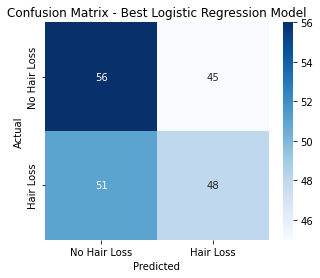

In [120]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, lg_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss','Hair Loss'],
    yticklabels=['No Hair Loss','Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Logistic Regression Model")
plt.show()

In [121]:
svc=SVC()
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'kernel': ['rbf']} 
grid_search = GridSearchCV(estimator = svc,  
                           param_grid = param_grid,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0)
grid_search.fit(X_train, y_train)

print('Parameters that give the best results :','\n\n', (grid_search.best_params_))
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))

Parameters that give the best results : 

 {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
GridSearch CV best score : 0.5545




In [122]:
svc=SVC(C=10,gamma=1,kernel='rbf',probability=True)
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Model accuracy score with these hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with these hyperparameters: 0.5300


In [123]:
print("=========== SVM Results ===========")
# Training predictions
svc_train_pred  = svc.predict(X_train)
svc_train_proba = svc.predict_proba(X_train)[:, 1]

print("\n--- TRAINING SET ---")
print("Accuracy       :", accuracy_score(y_train, svc_train_pred))
print("Precision      :", precision_score(y_train, svc_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, svc_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, svc_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, svc_train_proba))
print("Log Loss       :", log_loss(y_train, svc_train_proba))
print("Brier Score    :", brier_score_loss(y_train, svc_train_proba))

# Test predictions & probabilities
svc_test_pred  = svc.predict(X_test)
svc_test_proba = svc.predict_proba(X_test)[:, 1]

print("\n--- Test SET ---")
print("Accuracy       :", accuracy_score(y_test, svc_test_pred))
print("Precision      :", precision_score(y_test, svc_test_pred, zero_division=0))
print("Recall         :", recall_score(y_test, svc_test_pred, zero_division=0))
print("F1 Score       :", f1_score(y_test, svc_test_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_test, svc_test_proba))
print("Log Loss       :", log_loss(y_test, svc_test_proba))
print("Brier Score    :", brier_score_loss(y_test, svc_test_proba))

=========== SVM Results ===========

--- TRAINING SET ---
Accuracy       : 0.8948685857321652
Precision      : 0.8984771573604061
Recall         : 0.8894472361809045
F1 Score       : 0.893939393939394
ROC–AUC        : 0.9546516873645033
Log Loss       : 0.6364837728367906
Brier Score    : 0.2217381074827299

--- Test SET ---
Accuracy       : 0.53
Precision      : 0.5229357798165137
Recall         : 0.5757575757575758
F1 Score       : 0.548076923076923
ROC–AUC        : 0.5719071907190719
Log Loss       : 0.68744036162219
Brier Score    : 0.24714509126729184


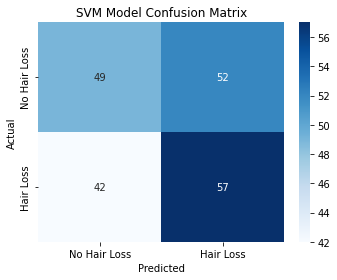

In [124]:
cm = confusion_matrix(y_test, svc_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss', 'Hair Loss'],
    yticklabels=['No Hair Loss', 'Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Model Confusion Matrix")
plt.tight_layout()
plt.show()

SVM ROC–AUC: 0.5719071907190719


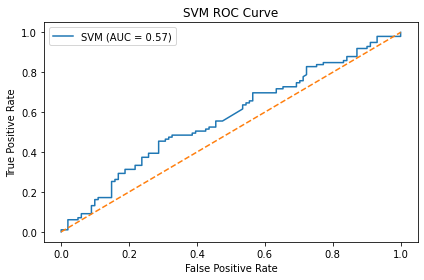

In [125]:
svc_test_proba = svc.predict_proba(X_test)[:, 1]
auc_svm = roc_auc_score(y_test,svc_test_proba)
print("SVM ROC–AUC:", auc_svm)

fpr, tpr, _ = roc_curve(y_test, svc_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [126]:
param_grid = {'n_neighbors':  range(1, 101, 2) , 
              'weights':['uniform', 'distance'], 
              'metric': ['euclidean', 'manhattan']}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(estimator = knn,  
                           param_grid = param_grid,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0)
grid_search.fit(X_train, y_train)
print('Parameters that give the best results :','\n\n', (grid_search.best_params_))
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))

Parameters that give the best results : 

 {'metric': 'euclidean', 'n_neighbors': 71, 'weights': 'distance'}
GridSearch CV best score : 0.5431




In [127]:
knn = KNeighborsClassifier(
        n_neighbors=71,
        weights='distance',
        metric='euclidean',
        )
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print('Model accuracy score with these hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))   

Model accuracy score with these hyperparameters: 0.5350


In [128]:
print("\n=========== KNN Results ===========")
# Training predictions & probabilities
knn_train_pred  = knn.predict(X_train)
knn_train_proba = knn.predict_proba(X_train)[:, 1]

print("\n--- TRAINING SET ---")
print("Accuracy       :", accuracy_score(y_train, knn_train_pred))
print("Precision      :", precision_score(y_train, knn_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, knn_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, knn_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, knn_train_proba))
print("Log Loss       :", log_loss(y_train, knn_train_proba))
print("Brier Score    :", brier_score_loss(y_train, knn_train_proba))

# Test predictions & probabilities
knn_test_pred  = knn.predict(X_test)
knn_test_proba = knn.predict_proba(X_test)[:, 1]

print("\n--- Test SET ---")
print("Accuracy       :", accuracy_score(y_test, knn_test_pred))
print("Precision      :", precision_score(y_test, knn_test_pred, zero_division=0))
print("Recall         :", recall_score(y_test, knn_test_pred, zero_division=0))
print("F1 Score       :", f1_score(y_test, knn_test_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_test, knn_test_proba))
print("Log Loss       :", log_loss(y_test, knn_test_proba))
print("Brier Score    :", brier_score_loss(y_test, knn_test_proba))


=========== KNN Results ===========

--- TRAINING SET ---
Accuracy       : 0.9774718397997497
Precision      : 1.0
Recall         : 0.9547738693467337
F1 Score       : 0.9768637532133677
ROC–AUC        : 0.9989849496860863
Log Loss       : 0.031230661452013513
Brier Score    : 0.011264080100125156

--- Test SET ---
Accuracy       : 0.535
Precision      : 0.5267857142857143
Recall         : 0.5959595959595959
F1 Score       : 0.5592417061611374
ROC–AUC        : 0.5786078607860786
Log Loss       : 2.330929442293427
Brier Score    : 0.26682043605874434


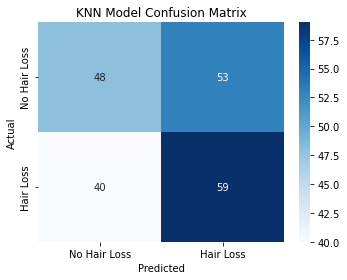

In [129]:
cm = confusion_matrix(y_test, knn_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss', 'Hair Loss'],
    yticklabels=['No Hair Loss', 'Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Model Confusion Matrix")
plt.tight_layout()
plt.show()